# Gráficos de barras simples

## 1. ¿Qué son y en qué consisten?

Son la manera más simple y más usada para visualizar la distribución de una variable categórica.

En el gráfico la frecuencia o proporción de cada categoría dentro de la variable es mostrada usando una barra.

## 2. ¿Cómo se obtiene un gráfico de barras?

El método más sencillo es usando la función `countplot()` de Seaborn.

Para entender cómo usar esta función comencemos leyendo el set de datos *data-prestamos.csv* que contiene 450961 registros de créditos otorgados por una entidad bancaria:

In [1]:
# Leer dataset
import pandas as pd

ruta = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/21-2024-03-Estadística-Descriptiva/datos/'

df = pd.read_csv(ruta + 'data-prestamos.csv')
df

,estado,nivel
0,Totalmente pagada,B
1,Cancelada (impago),C
2,Totalmente pagada,C
3,Totalmente pagada,C
4,Actual,B
...,...,...
450956,Actual,D
450957,Actual,D
450958,Actual,D
450959,Actual,D


Este set de datos contiene 2 variables categóricas (*estado* y *nivel*) indicando el estado del crédito y el nivel (asociado al monto: desde el monto G ("bajo") hasta el monto A para montos "altos").

Podemos dibujar el gráfico de barras de cada variable simplemente especificando la columna que queremos graficar:

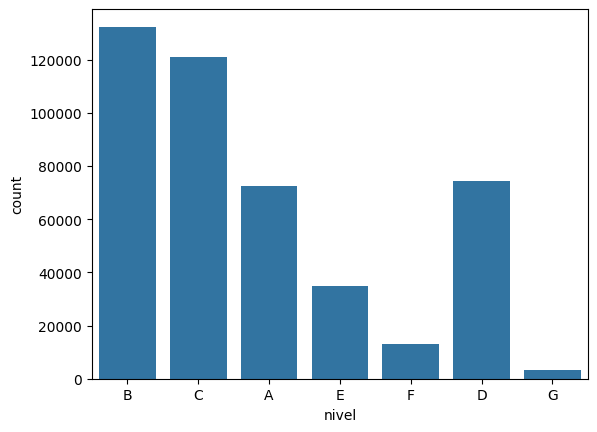

In [2]:
# ¿Cómo están distribuidos los niveles de los préstamos?
import seaborn as sns

ax = sns.countplot(df, x='nivel')

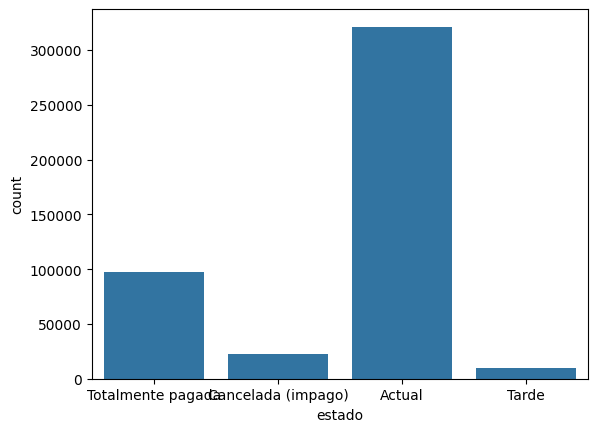

In [3]:
# ¿Y qué pasa con los estados?
ax = sns.countplot(df, x='estado')

Vemos que en cada caso el gráfico de barras muestra:

- Cada categoría (o nivel de la variable categórica) en el eje horizontal
- Y su respectivo conteo (número de veces que aparece en el set de datos) en el eje vertical

Aunque en ocasiones resulta más fácil interpretar la información de la gráfica mostrando porcentajes en lugar de conteos. Esto podemos hacerlo agregando el parámetro `stat='percent'` al momento de llamar la función:

In [4]:
sns.__version__

'0.13.0'

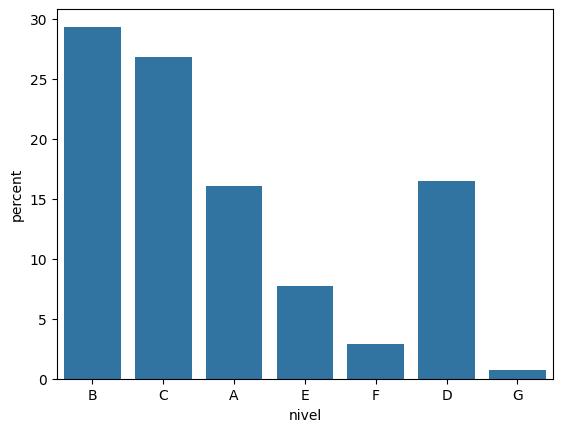

In [5]:
# Opción: mostrar porcentajes en lugar de conteos
ax=sns.countplot(df, x='nivel', stat='percent') # Requiere versión 0.13+ de seaborn

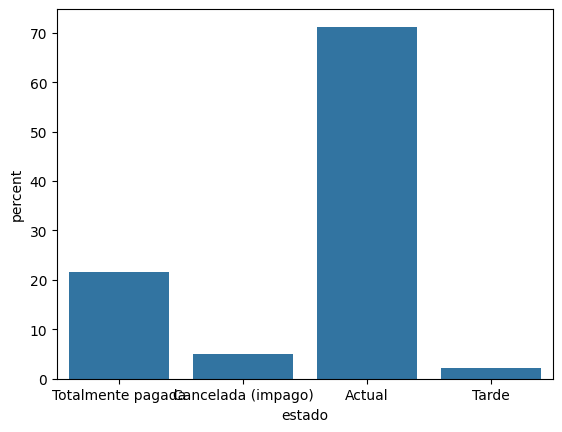

In [6]:
# Y algo similar para el caso de los estados
ax = sns.countplot(df, x='estado', stat='percent')

## 3. Opciones adicionales de visualización

Muchas veces resulta conveniente mostrar las barras de manera descendente (desde el mayor conteo/porcentaje hasta el menor).

Antes de hacerlo veamos cómo ordenar la variable de interés de manera descendente por conteo. Para ello podemos usar `value_counts()` de Pandas:

In [7]:
# Ordenar la variable "nivel" de manera descendente dependiendo de la frecuencia
df['nivel'].value_counts()

B    132370
C    120875
D     74277
A     72490
E     34804
F     12904
G      3241
Name: nivel, dtype: int64

Vemos que `value_counts()` simplemente calcula la frecuencia de cada categoría y genera como resultado una serie ordenada de forma ascendente donde:

- El índice contiene el nombre de la categoría (B, C, D, A, etc.)
- Y los valores corresponden al conteo de cada categoría (132370, 120875, 74277, etc.)

Para que `countplot()` muestre las barras ordenadas de manera descendente nos interesa únicamente presentarle el orden de las variables (no el conteo).

Este orden lo podemos extraer tomando símplemente el índice de la serie anterior:

In [8]:
# Orden en el que se deben mostrar las barras
df['nivel'].value_counts().index

Index(['B', 'C', 'D', 'A', 'E', 'F', 'G'], dtype='object')

Así que ya estamos listos para presentar esta información a `countplot()`: simplemente debemos agregar el parámetro `order` y allí especifica este orden:

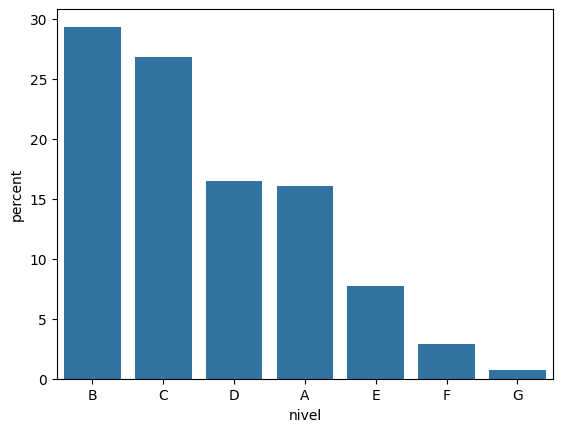

In [11]:
# Gráfico de barras para "nivel", en orden descendente y mostrando porcentajes
ax = sns.countplot(df, x='nivel', order = df['nivel'].value_counts().index, stat='percent')

Y hagamos lo mismo para el caso de la variable *estado*:

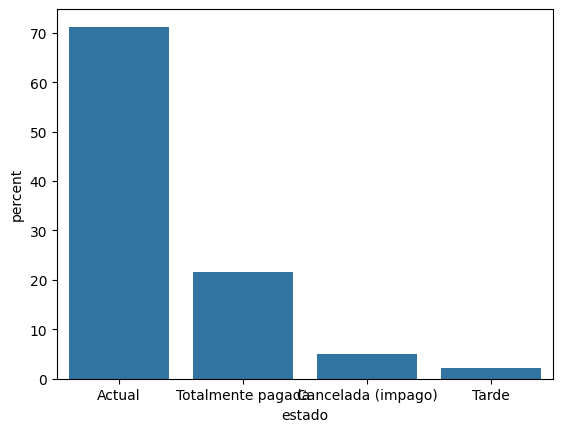

In [12]:
# Gráfico de barras para "estado", en orden descendente y mostrando porcentajes
ax = sns.countplot(df, x='estado', order = df['estado'].value_counts().index, stat='percent')

En el caso anterior podemos agregar una opción adicional de visualización: la rotación de las etiquetas del eje horizontal.

Esto lo podemos lograr tomando el objeto tipo *Axes* obtenido al generar la gráfica junto con el método `tick_params`:

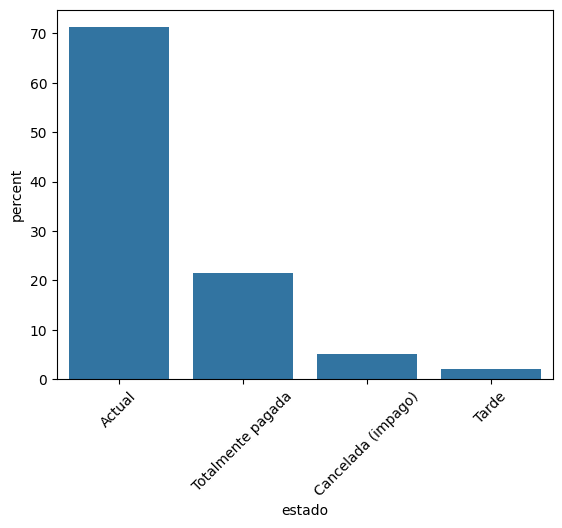

In [13]:
# Gráfico de barras para "estado", en orden descendente y mostrando porcentajes
ax = sns.countplot(df, x='estado', order = df['estado'].value_counts().index, stat='percent')

# Rotar etiquetas del eje x 45 grados
ax.tick_params(axis='x', rotation=45)

Y otra opción adicional es mostrar las barras con una orientación horizontal en lugar de vertical. Para lograr esto simplemente cambiamos `x` por `y` al momento de llamar `countplot()`:

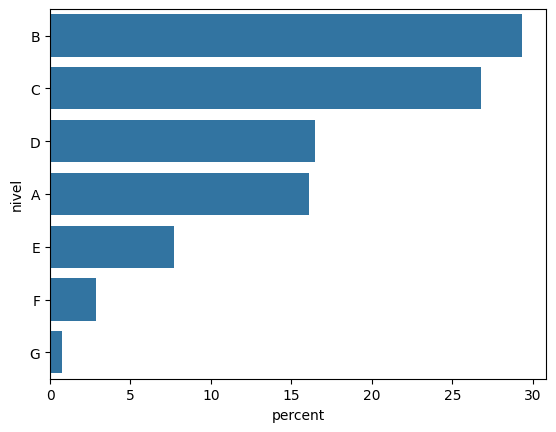

In [14]:
# Gráfico de barras horizontales para "nivel", en orden descendente y mostrando porcentajes
ax = sns.countplot(df, y='nivel', order = df['nivel'].value_counts().index, stat='percent')

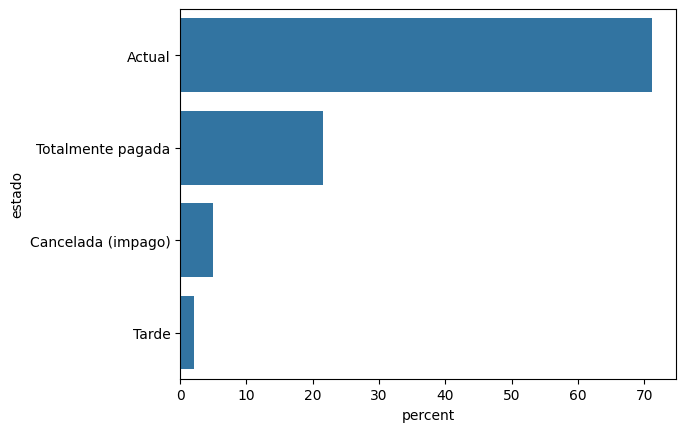

In [15]:
# Gráfico de barras para "estado", en orden descendente y mostrando porcentajes
ax = sns.countplot(df, y='estado', order = df['estado'].value_counts().index, stat='percent')

¡Y listo ya estamos listos para realizar el análisis exploratorio de cada una de estas variables!

## 4. Ejemplo práctico

Realizar el análisis univariado de las variables *estado* y *nivel*.

Acá simplemente generamos las mismas gráficas anteriores y después de cada una agregamos las respectivas observaciones.

Dibujaremos los gráficos de barras con estas características:
- Barras verticales
- Orden descendente
- Escala: porcentaje

Veamos qué ocurre con la variable *estado*:

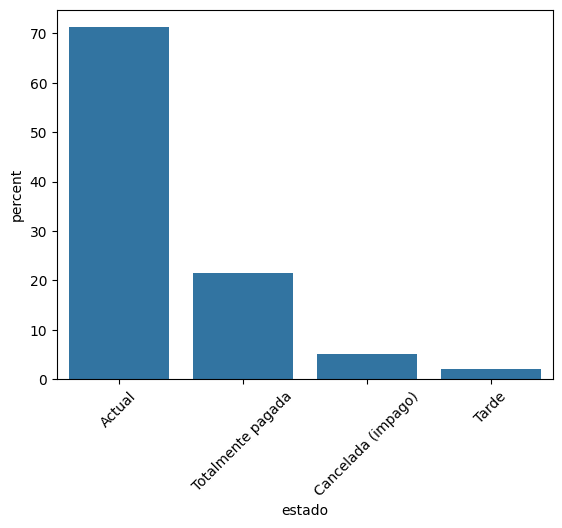

In [16]:
# Gráfico de barras para "estado", en orden descendente y mostrando porcentajes
ax = sns.countplot(df, x='estado', order = df['estado'].value_counts().index, stat='percent')

# Rotar etiquetas del eje x 45 grados
ax.tick_params(axis='x', rotation=45)

Observaciones:

- Casi el 70% de los créditos se encuentran activos actualmente (estado = Actual)
- Un poco más del 20% de los créditos ya ha sido pagado (estado = Totalmente pagada)
- Aproximadamente un 5% de los créditos no se pueden recuperar (estado = Cancelada (impago))
- El 3% restante están activos pero los deudores no los han pagado a tiempo (estado = Tarde)

Veamos ahora qué sucede con la variable *nivel*:

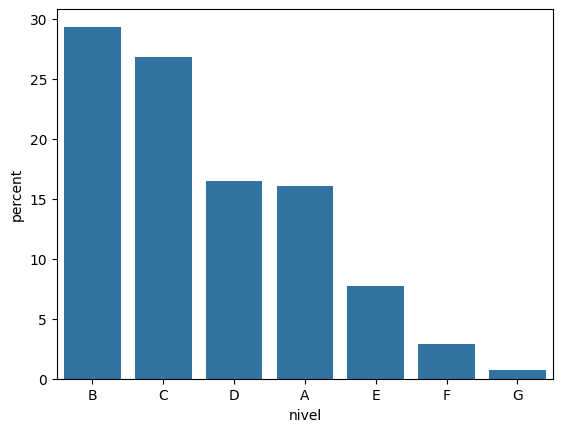

In [17]:
# Gráfico de barras para "nivel", en orden descendente y mostrando porcentajes
ax = sns.countplot(df, x='nivel', order = df['nivel'].value_counts().index, stat='percent')

Observaciones (como son demasiados niveles podemos agruparlos para tener una idea general de la distribución):

- Tenemos 7 diferentes niveles de crédito, siendo A los créditos con montos más altos y G con los montos más bajos
- Aproximadamente el 70% de los créditos otorgados son de niveles medio-alto (B, C, D)
- El 15% de los créditos otorgados son de niveles altos (A)
- Aproximadamente el 15% de los créditos restantes son de niveles medio-bajo (E, F, G)

En este análisis resultaría interesante ver por ejemplo si los créditos con montos altos o con montos bajos son más propensos a ser pagados o a pasar al estado de "impago". Pero esto implica analizar las dos variables de manera simultánea. Esto lo veremos en el último módulo cuando hablemos del análisis bivariado.

## 5. Aspectos a tener en cuenta

- Los gráficos de barras simples son la manera más sencilla de analizar el comportamiento de variables categóricas
- Cada gráfico muestra, a través de una barra, la frecuencia o porcentaje que cada categoría representa dentro de la variable
- `countplot()` de Seaborn ofrece una forma muy sencilla de generar este tipo de gráfica